In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

sns.set(color_codes=True)

%matplotlib inline

In [2]:
df = pd.read_csv("data/combinedfile.csv")

In [3]:
df.head()

,ReportDate,API_WELLNO,FileNo,Company,WellName,Quarter,Section,Township,Range,County,...,Pool,Oil,Wtr,Days,Runs,Gas,GasSold,Flared,Lat,Long
0,8/1/17,3.305300e+13,23615,MUREX PETROLEUM CORPORATION,AMBER ELIZABETH 36-25H,SESW,36,151,101,MCK,...,BAKKEN,2339.0,2412.0,31.0,2222,3624.0,3139,95.0,47.849140,-103.553342
1,8/1/17,3.305300e+13,22021,STATOIL OIL & GAS LP,BILL 14-23 2TFH,SWSW,11,151,101,MCK,...,BAKKEN,1471.0,2758.0,31.0,1513,1615.0,1447,137.0,47.907426,-103.579904
2,8/1/17,3.305300e+13,25091,STATOIL OIL & GAS LP,BILL 14-23 3H,NWNE,14,151,101,MCK,...,BAKKEN,3291.0,5568.0,31.0,3234,2774.0,2692,51.0,47.904553,-103.569154
3,8/1/17,3.305310e+13,25645,STATOIL OIL & GAS LP,BILL 14-23 4TFH,NWNE,14,151,101,MCK,...,BAKKEN,0.0,0.0,31.0,0,0.0,0,0.0,47.904553,-103.569032
4,8/1/17,3.305300e+13,25092,STATOIL OIL & GAS LP,BILL 14-23 5TFH,NWNE,14,151,101,MCK,...,BAKKEN,0.0,0.0,31.0,0,0.0,0,0.0,47.904553,-103.569276


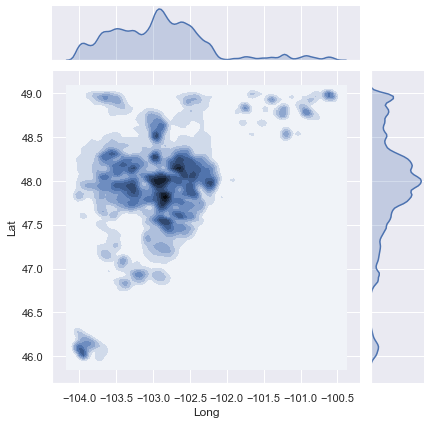

In [5]:
sns.jointplot(x="Long", y="Lat", data=df, kind="kde");

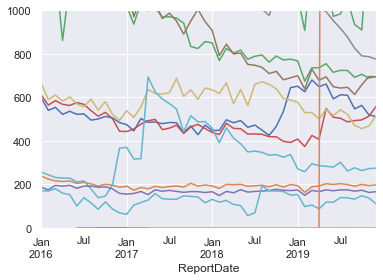

In [37]:
df.pivot_table(index="ReportDate", columns="API_WELLNO_category", values="Oil").plot(
    legend=False, ylim=(0, 1000)
)

In [3]:
df["Name"] = df["WellName"].astype("category")

In [4]:
df.set_index(["Name", "ReportDate"], inplace=True)

In [5]:
df.head()

,,API_WELLNO,FileNo,Company,WellName,Quarter,Section,Township,Range,County,FieldName,Pool,Oil,Wtr,Days,Runs,Gas,GasSold,Flared,Lat,Long
Name,ReportDate,,,,,,,,,,,,,,,,,,,,
AMBER ELIZABETH 36-25H,8/1/17,3.305300e+13,23615,MUREX PETROLEUM CORPORATION,AMBER ELIZABETH 36-25H,SESW,36,151,101,MCK,ALEXANDER,BAKKEN,2339.0,2412.0,31.0,2222,3624.0,3139,95.0,47.849140,-103.553342
BILL 14-23 2TFH,8/1/17,3.305300e+13,22021,STATOIL OIL & GAS LP,BILL 14-23 2TFH,SWSW,11,151,101,MCK,ALEXANDER,BAKKEN,1471.0,2758.0,31.0,1513,1615.0,1447,137.0,47.907426,-103.579904
BILL 14-23 3H,8/1/17,3.305300e+13,25091,STATOIL OIL & GAS LP,BILL 14-23 3H,NWNE,14,151,101,MCK,ALEXANDER,BAKKEN,3291.0,5568.0,31.0,3234,2774.0,2692,51.0,47.904553,-103.569154
BILL 14-23 4TFH,8/1/17,3.305310e+13,25645,STATOIL OIL & GAS LP,BILL 14-23 4TFH,NWNE,14,151,101,MCK,ALEXANDER,BAKKEN,0.0,0.0,31.0,0,0.0,0,0.0,47.904553,-103.569032
BILL 14-23 5TFH,8/1/17,3.305300e+13,25092,STATOIL OIL & GAS LP,BILL 14-23 5TFH,NWNE,14,151,101,MCK,ALEXANDER,BAKKEN,0.0,0.0,31.0,0,0.0,0,0.0,47.904553,-103.569276


In [6]:
grouped = df.groupby("Name")["Oil"]
names = grouped.agg([np.sum, np.mean, np.std, np.max])

In [7]:
type(names)

pandas.core.frame.DataFrame

In [8]:
df.reset_index(inplace=True)
df_outer = pd.merge(df, names, on="Name", how="outer")

In [9]:
df1 = df_outer.copy()

In [75]:
df_outer["local_scaled"] = df_outer["Oil"] / df_outer["amax"]

In [77]:
df_outer.set_index("ReportDate", inplace=True)

In [12]:
df1.set_index(["Name", "ReportDate"], inplace=True)

In [26]:
df1["Oil"].plot()

ValueError: Index contains duplicate entries, cannot reshape

In [21]:
df1.head()

API_WELLNO  FileNo  \
Name                    ReportDate                         
AMBER ELIZABETH  36-25H 8/1/17      3.305300e+13   23615   
                        9/1/16      3.305300e+13   23615   
                        1/1/18      3.305300e+13   23615   
                        12/1/17     3.305300e+13   23615   
                        4/1/17      3.305300e+13   23615   

                                                        Company  \
Name                    ReportDate                                
AMBER ELIZABETH  36-25H 8/1/17      MUREX PETROLEUM CORPORATION   
                        9/1/16      MUREX PETROLEUM CORPORATION   
                        1/1/18      MUREX PETROLEUM CORPORATION   
                        12/1/17     MUREX PETROLEUM CORPORATION   
                        4/1/17      MUREX PETROLEUM CORPORATION   

                                                   WellName Quarter  Section  \
Name                    ReportDate                                             
AMBER ELIZABETH  36-25H 8/1/17      AMBER ELIZABETH  36-25H    SESW       36   
                        9/1/16      AMBER ELIZABETH  36-25H    SESW       36   
                        1/1/18      AMBER ELIZABETH  36-25H    SESW       36   
                        12/1/17     AMBER ELIZABETH  36-25H    SESW       36   
                        4/1/17      AMBER ELIZABETH  36-25H    SESW       36   

                                    Township  Range County  FieldName  ...  \
Name                    ReportDate                                     ...   
AMBER ELIZABETH  36-25H 8/1/17           151    101    MCK  ALEXANDER  ...   
                        9/1/16           151    101    MCK  ALEXANDER  ...   
                        1/1/18           151    101    MCK  ALEXANDER  ...   
                        12/1/17          151    101    MCK  ALEXANDER  ...   
                        4/1/17           151    101    MCK  ALEXANDER  ...   

                                    Runs     Gas  GasSold  Flared       Lat  \
Name                    ReportDate                                            
AMBER ELIZABETH  36-25H 8/1/17      2222  3624.0     3139    95.0  47.84914   
                        9/1/16      1242  1368.0      894    84.0  47.84914   
                        1/1/18       982  3037.0     2598    36.0  47.84914   
                        12/1/17     1462  2522.0     2072    47.0  47.84914   
                        4/1/17      1454  1560.0     1157    13.0  47.84914   

                                          Long      sum         mean  \
Name                    ReportDate                                     
AMBER ELIZABETH  36-25H 8/1/17     -103.553342  63674.0  1326.541667   
                        9/1/16     -103.553342  63674.0  1326.541667   
                        1/1/18     -103.553342  63674.0  1326.541667   
                        12/1/17    -103.553342  63674.0  1326.541667   
                        4/1/17     -103.553342  63674.0  1326.541667   

                                           std    amax  
Name                    ReportDate                      
AMBER ELIZABETH  36-25H 8/1/17      335.445271  2339.0  
                        9/1/16      335.445271  2339.0  
                        1/1/18      335.445271  2339.0  
                        12/1/17     335.445271  2339.0  
                        4/1/17      335.445271  2339.0  

[5 rows x 24 columns]

In [27]:
df1.to_csv("Bakken Production.csv")